In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)
np.random.seed(42)
print("Setup complete.")

Setup complete.


In [3]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame  # already has a 'target' column
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()         
model.fit(X_train, y_train)      
y_pred = model.predict(X_test)     

r2 = r2_score(y_test, y_pred)                  
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2  : {r2:.3f}")
print(f"MAE  : {mae:.3f}  (in units of the target, i.e. $100,000s)")

R^2  : 0.453
MAE  : 42.794  (in units of the target, i.e. $100,000s)


In [5]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

print(f"\nMost influential feature: '{coefs.index[0]}' "
      f"(coefficient = {coefs.iloc[0]:.3f})")
print("A positive coefficient means the feature increases the predicted value;")
print("a negative coefficient means it decreases it. Larger |coefficient| = bigger effect")
print("per unit change — but only directly comparable if features are on similar scales,")
print("otherwise scale the features first before comparing magnitudes fairly.")

s1    -931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex   -241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64

Most influential feature: 's1' (coefficient = -931.489)
A positive coefficient means the feature increases the predicted value;
a negative coefficient means it decreases it. Larger |coefficient| = bigger effect
per unit change — but only directly comparable if features are on similar scales,
otherwise scale the features first before comparing magnitudes fairly.


In [6]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Linear Regression -> R^2: {r2:.3f}, MAE: {mae:.3f}")
print(f"Random Forest     -> R^2: {rf_r2:.3f}, MAE: {rf_mae:.3f}")

if rf_r2 > r2:
    print("\nYes — the Random Forest improves R^2 on the test set.")
    print("Tree ensembles can capture non-linear relationships that plain")
    print("Linear Regression misses.")
else:
    print("\nIn this run the Random Forest did not beat Linear Regression.")

Linear Regression -> R^2: 0.453, MAE: 42.794
Random Forest     -> R^2: 0.440, MAE: 44.276

In this run the Random Forest did not beat Linear Regression.


In [7]:
#17.3
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df_c = cancer.frame
df_c.rename(columns={"target": "label"}, inplace=True)
# target: 0 = malignant, 1 = benign
print(cancer.target_names)
df_c.head()

['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
Xc = df_c.drop(columns=["label"])
yc = df_c["label"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

# Logistic Regression benefits from scaled features
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

clf = LogisticRegression(max_iter=5000)
clf.fit(Xc_train_scaled, yc_train)
yc_pred = clf.predict(Xc_test_scaled)

print(classification_report(yc_test, yc_pred, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



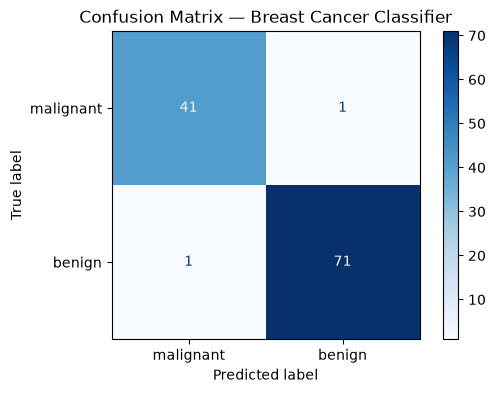

True Negatives  (correctly predicted malignant): 41
False Positives (predicted benign, actually malignant): 1  <-- dangerous type of error
False Negatives (predicted malignant, actually benign): 1
True Positives  (correctly predicted benign): 71


In [9]:
cm = confusion_matrix(yc_test, yc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Breast Cancer Classifier")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted malignant): {tn}")
print(f"False Positives (predicted benign, actually malignant): {fp}  <-- dangerous type of error")
print(f"False Negatives (predicted malignant, actually benign): {fn}")
print(f"True Positives  (correctly predicted benign): {tp}")

In [10]:
probs = clf.predict_proba(Xc_test_scaled)[:, 1]  # probability of class '1' = benign

top5_idx = np.argsort(probs)[::-1][:5]  # highest probability first

results = pd.DataFrame({
    "sample_index": Xc_test.iloc[top5_idx].index,
    "predicted_probability_benign": probs[top5_idx],
    "actual_label": yc_test.iloc[top5_idx].map({0: "malignant", 1: "benign"}).values
})
results

,sample_index,predicted_probability_benign,actual_label
0,296,1.000000,benign
1,307,0.999999,benign
2,140,0.999998,benign
3,354,0.999989,benign
4,428,0.999989,benign


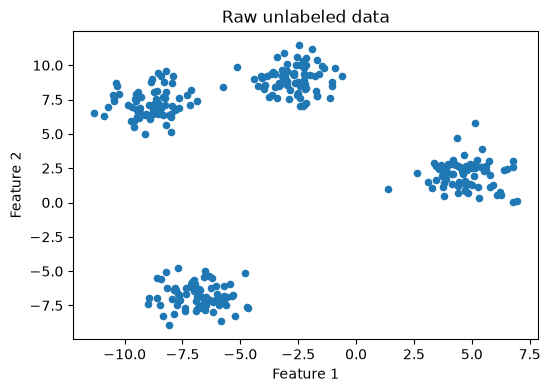

In [11]:
from sklearn.datasets import make_blobs

X_blob, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=20)
plt.title("Raw unlabeled data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

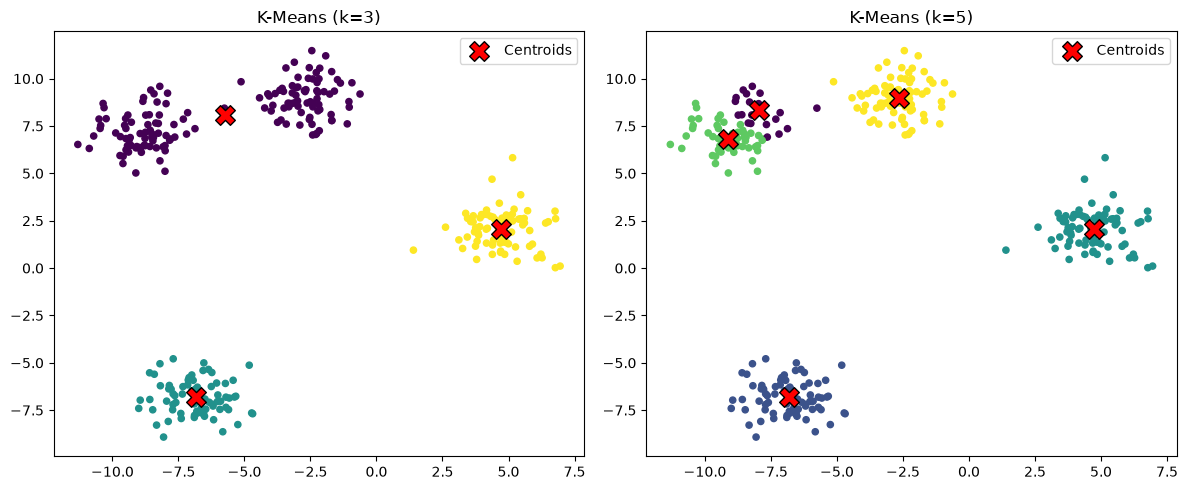

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, k in zip(axes, [3, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="viridis", s=20)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c="red", marker="X", s=200, edgecolor="black", label="Centroids")
    ax.set_title(f"K-Means (k={k})")
    ax.legend()

plt.tight_layout()
plt.show()

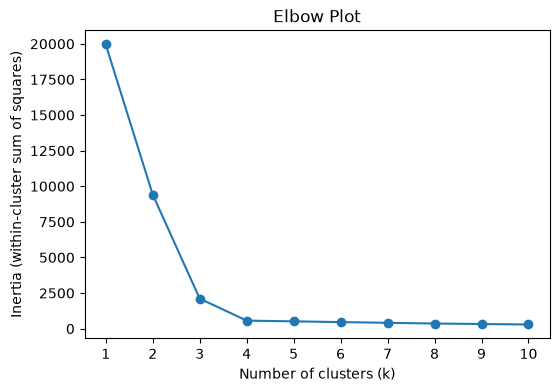

Look for the 'elbow' — the point where the curve stops dropping sharply
and starts to flatten. For this dataset (generated with 4 true centers),
the elbow should appear around k=4.


In [13]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blob)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Plot")
plt.xticks(list(k_range))
plt.show()

print("Look for the 'elbow' — the point where the curve stops dropping sharply")
print("and starts to flatten. For this dataset (generated with 4 true centers),")
print("the elbow should appear around k=4.")

In [14]:
best_k = 4  # chosen from the elbow plot above
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_blob)

df_blob = pd.DataFrame(X_blob, columns=["Feature_1", "Feature_2"])
df_blob["cluster"] = cluster_labels

cluster_summary = df_blob.groupby("cluster").mean()
print("Average feature values per cluster:")
print(cluster_summary)

# Example naming logic — in a real project you'd use domain knowledge
# (e.g., "high spenders", "low income - high frequency", etc.)
names = {}
for c in cluster_summary.index:
    f1, f2 = cluster_summary.loc[c]
    names[c] = f"Cluster {c}: Feature_1~{f1:.1f}, Feature_2~{f2:.1f}"

for c, name in names.items():
    print(name)

print("\nIn a real-world dataset, replace 'Feature_1 / Feature_2' with meaningful")
print("column names (e.g., 'avg_purchase', 'visit_frequency') so each cluster can")
print("be given a human-readable label like 'High-value frequent shoppers'.")

Average feature values per cluster:
         Feature_1  Feature_2
cluster                      
0        -2.709811   8.971433
1        -6.832352  -6.830457
2         4.718205   2.041797
3        -8.873572   7.174583
Cluster 0: Feature_1~-2.7, Feature_2~9.0
Cluster 1: Feature_1~-6.8, Feature_2~-6.8
Cluster 2: Feature_1~4.7, Feature_2~2.0
Cluster 3: Feature_1~-8.9, Feature_2~7.2

In a real-world dataset, replace 'Feature_1 / Feature_2' with meaningful
column names (e.g., 'avg_purchase', 'visit_frequency') so each cluster can
be given a human-readable label like 'High-value frequent shoppers'.


In [15]:
# Titanic dataset — end-to-end classification example
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    titanic = pd.read_csv(titanic_url)
    print("Loaded Titanic dataset from URL.")
except Exception as e:
    print("Could not fetch from URL (no internet access in this environment).")
    print("To run this cell yourself: download 'titanic.csv' from Kaggle")
    print("(https://www.kaggle.com/c/titanic/data) and use pd.read_csv('titanic.csv') instead.")
    titanic = None

if titanic is not None:
    print(titanic.shape)
    titanic.head()

Loaded Titanic dataset from URL.
(891, 12)


                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



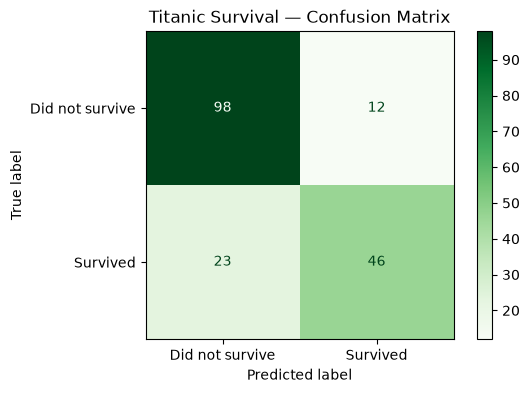

In [16]:
if titanic is not None:
    # 1. Basic cleaning / feature selection
    features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
    data = titanic[features + ["Survived"]].copy()

    # Fill missing values
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

    # Encode categoricals
    data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
    data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)

    X_t = data.drop(columns=["Survived"])
    y_t = data["Survived"]

    # 2. Split (stratify to preserve survival ratio in both sets)
    Xt_train, Xt_test, yt_train, yt_test = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
    )

    # 3. Scale + train
    scaler_t = StandardScaler()
    Xt_train_s = scaler_t.fit_transform(Xt_train)
    Xt_test_s = scaler_t.transform(Xt_test)

    titanic_clf = LogisticRegression(max_iter=5000)
    titanic_clf.fit(Xt_train_s, yt_train)
    yt_pred = titanic_clf.predict(Xt_test_s)

    # 4. Evaluate
    print(classification_report(yt_test, yt_pred, target_names=["Did not survive", "Survived"]))

    cm_t = confusion_matrix(yt_test, yt_pred)
    ConfusionMatrixDisplay(cm_t, display_labels=["Did not survive", "Survived"]).plot(cmap="Greens")
    plt.title("Titanic Survival — Confusion Matrix")
    plt.show()